# Week 1 Data Wrangling: Heart Attack Dataset

This notebook cleans and explores three patient datasets from separate systems:
- Administrative / demographics
- Clinical / lab measurements
- Lifestyle factors

The goal is to create an analysis-ready dataset and document the cleaning decisions along the way.

## What this notebook does

1. Inspects the three source files.
2. Cleans and standardizes each dataset.
3. Splits the blood pressure string into numeric systolic and diastolic columns.
4. Builds a merged analysis-ready table.
5. Performs univariate, bivariate, and correlation analysis.
6. Records the final findings in a short reflection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load the source files

The CSV files live in the same folder as this notebook, so the paths can stay simple and portable.

In [2]:
base = Path('.')

demographics = pd.read_csv(base / 'patient_demographics.csv')
clinical = pd.read_csv(base / 'clinical_data.csv')
lifestyle = pd.read_csv(base / 'lifestyle_factors.csv')

print('Demographics:', demographics.shape)
print('Clinical:', clinical.shape)
print('Lifestyle:', lifestyle.shape)

Demographics: (8763, 7)
Clinical: (8763, 8)
Lifestyle: (8763, 8)


## Initial inspection

These checks show the shape, column names, data types, missing values, and duplicate patient IDs. The datasets are already fairly clean, so this notebook focuses on validation and standardization rather than aggressive imputation.

In [3]:
datasets = {
    'demographics': demographics,
    'clinical': clinical,
    'lifestyle': lifestyle,
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print('shape:', df.shape)
    print('columns:', list(df.columns))
    print('missing values:\n', df.isna().sum())
    print('duplicate Patient ID count:', df['Patient ID'].duplicated().sum())
    display(df.head(3))


DEMOGRAPHICS
shape: (8763, 7)
columns: ['Patient ID', 'Age', 'Sex', 'Income', 'Country', 'Continent', 'Hemisphere']
missing values:
 Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64
duplicate Patient ID count: 0


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere



CLINICAL
shape: (8763, 8)
columns: ['Patient ID', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes', 'Family History', 'Triglycerides', 'BMI']
missing values:
 Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
dtype: int64
duplicate Patient ID count: 0


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571



LIFESTYLE
shape: (8763, 8)
columns: ['Patient ID', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Stress Level', 'Heart Attack Risk']
missing values:
 Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64
duplicate Patient ID count: 0


,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0


## Cleaning and standardization

The main cleaning step is converting the blood pressure string into two numeric features. The other columns are already well-formed, so they mainly need type conversion and light standardization.

In [4]:
def clean_text(series):
    return series.astype('string').str.strip()

# Standardize text columns
for frame, columns in [
    (demographics, ['Sex', 'Country', 'Continent', 'Hemisphere']),
    (lifestyle, ['Diet']),
]:
    for column in columns:
        frame[column] = clean_text(frame[column])

# Convert numeric columns
for column in ['Age', 'Income']:
    demographics[column] = pd.to_numeric(demographics[column], errors='coerce').astype('Int64')

for column in ['Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Triglycerides', 'BMI']:
    clinical[column] = pd.to_numeric(clinical[column], errors='coerce')

for column in ['Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Stress Level', 'Heart Attack Risk']:
    lifestyle[column] = pd.to_numeric(lifestyle[column], errors='coerce')

# Split blood pressure into two numeric columns
blood_pressure = clinical['Blood Pressure'].astype('string').str.extract(r'(?P<Systolic>\d+)\s*/\s*(?P<Diastolic>\d+)')
clinical['Systolic'] = pd.to_numeric(blood_pressure['Systolic'], errors='coerce').astype('Int64')
clinical['Diastolic'] = pd.to_numeric(blood_pressure['Diastolic'], errors='coerce').astype('Int64')
clinical = clinical.drop(columns=['Blood Pressure'])

# Merge the cleaned datasets into one analysis-ready table
analysis_df = demographics.merge(clinical, on='Patient ID').merge(lifestyle, on='Patient ID')
print('Merged shape:', analysis_df.shape)
display(analysis_df.head())

Merged shape: (8763, 22)


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere,Cholesterol,Heart Rate,Diabetes,...,BMI,Systolic,Diastolic,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere,208,72,0,...,31.251233,158,88,1,0,0,4.168189,Average,9,0
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere,389,98,1,...,27.194973,165,93,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere,324,72,1,...,28.176571,174,99,0,0,0,2.078353,Healthy,9,0
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere,383,73,1,...,36.464704,163,100,1,0,1,9.828130,Average,9,0
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere,318,93,1,...,21.809144,91,88,1,1,0,5.804299,Unhealthy,6,0


## Cleaning checks

Because the source files already had complete rows, the notebook checks for malformed blood pressure values, duplicate patient IDs, and out-of-range numbers instead of filling missing data that does not exist.

In [5]:
print('Missing values in analysis table:')
print(analysis_df.isna().sum().sort_values(ascending=False))

print('\nDuplicate Patient ID count:', analysis_df['Patient ID'].duplicated().sum())
print('Malformed blood pressure rows after parsing:', analysis_df[['Systolic', 'Diastolic']].isna().any(axis=1).sum())

range_checks = {
    'Age': (analysis_df['Age'].between(0, 120).all()),
    'BMI': (analysis_df['BMI'].between(10, 60).all()),
    'Cholesterol': (analysis_df['Cholesterol'].between(100, 500).all()),
    'Heart Rate': (analysis_df['Heart Rate'].between(35, 220).all()),
    'Systolic': (analysis_df['Systolic'].between(70, 250).all()),
    'Diastolic': (analysis_df['Diastolic'].between(40, 150).all()),
    'Exercise Hours Per Week': (analysis_df['Exercise Hours Per Week'].between(0, 24).all()),
}
print('\nRange checks:')
for field, ok in range_checks.items():
    print(f'{field}:', 'OK' if ok else 'Needs review')

Missing values in analysis table:
Patient ID                 0
Age                        0
Sex                        0
Income                     0
Country                    0
Continent                  0
Hemisphere                 0
Cholesterol                0
Heart Rate                 0
Diabetes                   0
Family History             0
Triglycerides              0
BMI                        0
Systolic                   0
Diastolic                  0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

Duplicate Patient ID count: 0
Malformed blood pressure rows after parsing: 0

Range checks:
Age: OK
BMI: OK
Cholesterol: OK
Heart Rate: OK
Systolic: OK
Diastolic: OK
Exercise Hours Per Week: OK


## Univariate analysis

These charts summarize the distribution of the most important numeric and categorical variables before comparing them to the target.

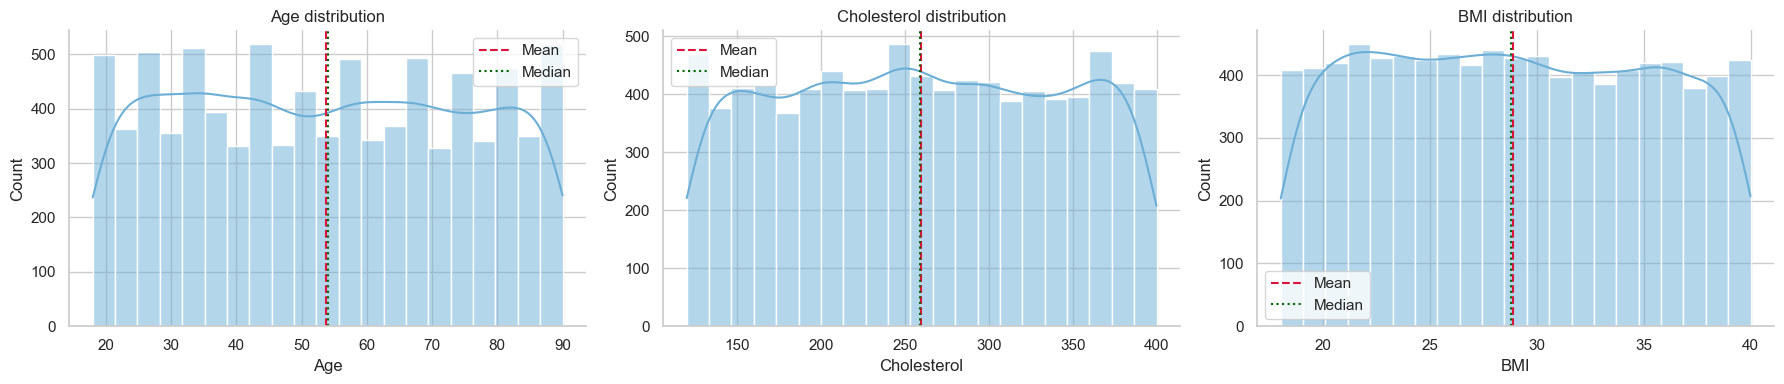

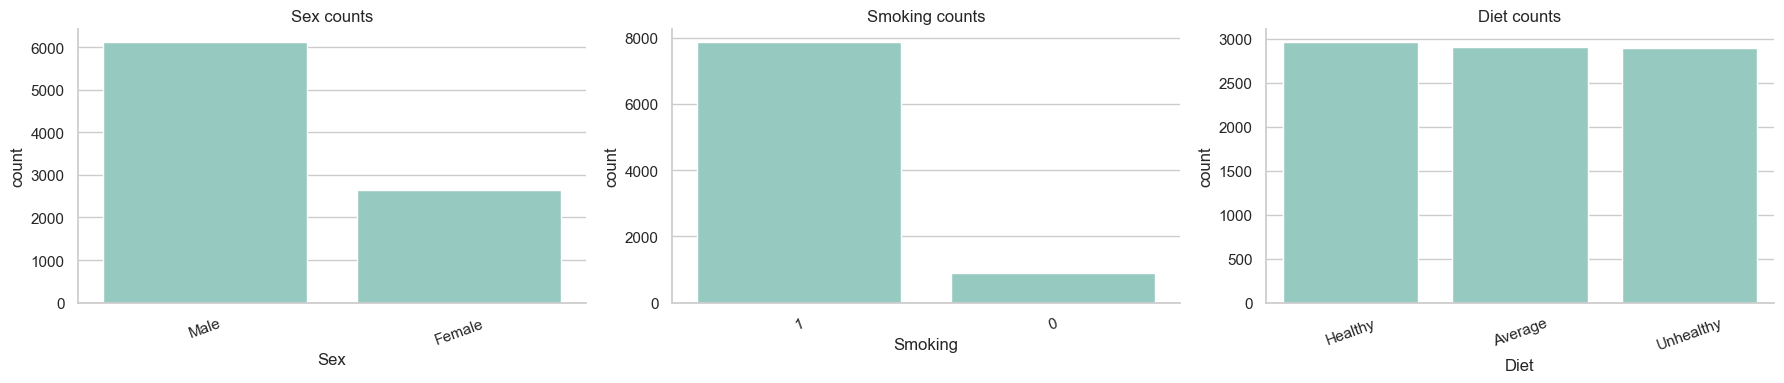

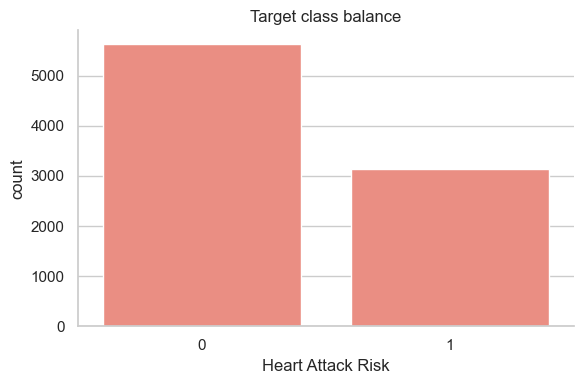

In [7]:
numeric_features = ['Age', 'Cholesterol', 'BMI']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, feature in zip(axes, numeric_features):
    sns.histplot(data=analysis_df, x=feature, kde=True, ax=axis, color='#6baed6')
    axis.axvline(analysis_df[feature].mean(), color='crimson', linestyle='--', label='Mean')
    axis.axvline(analysis_df[feature].median(), color='darkgreen', linestyle=':', label='Median')
    axis.set_title(f'{feature} distribution')
    axis.legend()
plt.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, feature in zip(axes, ['Sex', 'Smoking', 'Diet']):
    order = analysis_df[feature].value_counts().index
    sns.countplot(data=analysis_df, x=feature, order=order, ax=axis, color='#8dd3c7')
    axis.set_title(f'{feature} counts')
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()

plt.figure(figsize=(6, 4))
sns.countplot(data=analysis_df, x='Heart Attack Risk', color='#fb8072')
plt.title('Target class balance')
plt.tight_layout()

## Bivariate analysis

The next step is comparing risk across groups and checking whether any single feature has a visible relationship with the target.

Risk rate by Smoking
Smoking
0    0.363938
1    0.357552

Risk rate by Diet
Diet
Average      0.352335
Healthy      0.364527
Unhealthy    0.357662

Risk rate by Sex
Sex
Female    0.355958
Male      0.359188


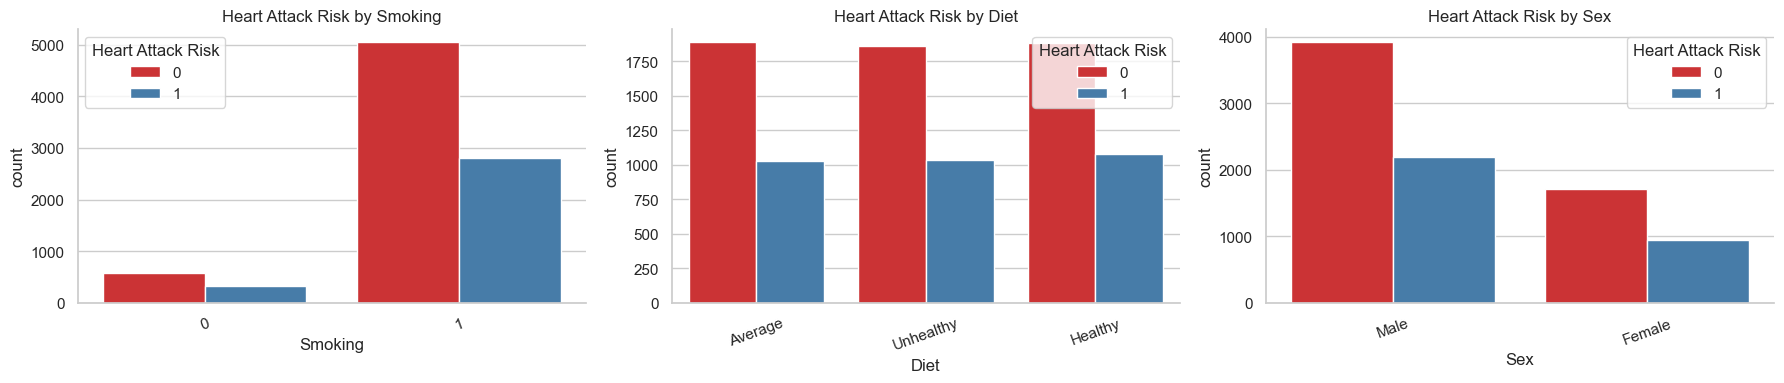

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, feature in zip(axes, ['Smoking', 'Diet', 'Sex']):
    sns.countplot(data=analysis_df, x=feature, hue='Heart Attack Risk', ax=axis, palette='Set1')
    axis.set_title(f'Heart Attack Risk by {feature}')
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()

print('Risk rate by Smoking')
print(analysis_df.groupby('Smoking')['Heart Attack Risk'].mean().to_string())
print('\nRisk rate by Diet')
print(analysis_df.groupby('Diet')['Heart Attack Risk'].mean().to_string())
print('\nRisk rate by Sex')
print(analysis_df.groupby('Sex')['Heart Attack Risk'].mean().to_string())

## Correlation analysis

Pearson measures linear relationships while Spearman measures monotonic rank relationships. Comparing both helps show whether any pattern is driven by a non-linear trend or an outlier.

Top Pearson correlations with Heart Attack Risk
Cholesterol                0.019340
Systolic                   0.018585
Diabetes                   0.017225
Alcohol Consumption        0.013778
Obesity                    0.013318
Exercise Hours Per Week    0.011133
Triglycerides              0.010471
Income                     0.009628

Top Spearman correlations with Heart Attack Risk
Cholesterol                0.019271
Systolic                   0.018642
Diabetes                   0.017225
Alcohol Consumption        0.013778
Obesity                    0.013318
Exercise Hours Per Week    0.011166
Triglycerides              0.010452
Income                     0.009586


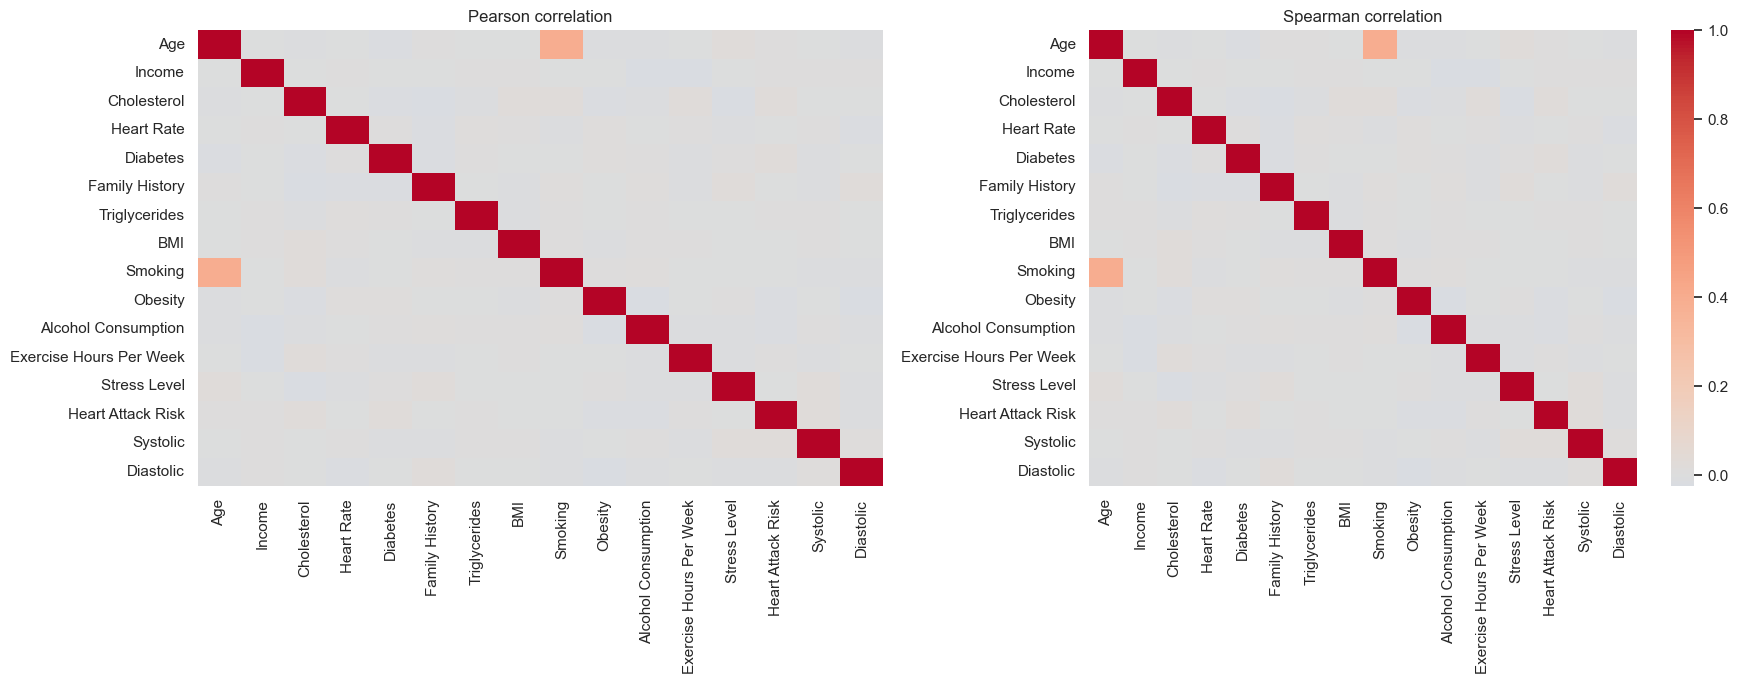

In [9]:
numeric_columns = [
    'Age', 'Income', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
    'Triglycerides', 'BMI', 'Smoking', 'Obesity', 'Alcohol Consumption',
    'Exercise Hours Per Week', 'Stress Level', 'Heart Attack Risk', 'Systolic', 'Diastolic'
]

pearson_corr = analysis_df[numeric_columns].corr(method='pearson')
spearman_corr = analysis_df[numeric_columns].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr, cmap='coolwarm', center=0, ax=axes[0], cbar=False)
axes[0].set_title('Pearson correlation')
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Spearman correlation')
plt.tight_layout()

print('Top Pearson correlations with Heart Attack Risk')
print(pearson_corr['Heart Attack Risk'].drop('Heart Attack Risk').abs().sort_values(ascending=False).head(8).to_string())
print('\nTop Spearman correlations with Heart Attack Risk')
print(spearman_corr['Heart Attack Risk'].drop('Heart Attack Risk').abs().sort_values(ascending=False).head(8).to_string())

## Save cleaned outputs

The cleaned tables are saved so the work can be reused later without rerunning every step manually.

In [10]:
demographics.to_csv(base / 'patient_demographics_cleaned.csv', index=False)
clinical.to_csv(base / 'clinical_data_cleaned.csv', index=False)
lifestyle.to_csv(base / 'lifestyle_factors_cleaned.csv', index=False)
analysis_df.to_csv(base / 'heart_attack_analysis_ready.csv', index=False)

print('Saved cleaned CSV files and the merged analysis-ready dataset.')

Saved cleaned CSV files and the merged analysis-ready dataset.


## Final reflection

**1. Missing values**  
The source files did not contain missing values, so no imputation or row dropping was needed. I kept every record and focused on type conversion and standardization.

**2. Data quality issues**  
The main quality issue was the blood pressure field being stored as a string like `158/88`. I split that column into numeric systolic and diastolic fields so the values can be analyzed. I also checked for duplicate patient IDs and unrealistic numeric ranges; none required removal.

**3. Insights from EDA**  
The dataset is reasonably balanced, with 5,624 patients in the no-risk class and 3,139 in the at-risk class. Sex is also unevenly distributed, with more male than female patients. The numeric distributions are usable for analysis, and BMI, cholesterol, and blood pressure can now be compared directly.

**4. Correlation findings**  
The Pearson and Spearman heatmaps are very similar, which suggests there are no strong non-linear effects or outlier-driven relationships in the current numeric features. The strongest individual correlations with heart attack risk are still quite weak, which suggests the target is probably influenced by a combination of factors rather than one dominant variable.

**5. Improvements**  
If I had more time, I would test feature engineering ideas such as blood-pressure categories, risk-group comparisons, and interaction terms. I would also explore multivariate modeling to see whether a combination of lifestyle and clinical variables predicts risk better than simple one-variable comparisons.